<a href="https://colab.research.google.com/github/akankshajv/Urban-Infrastructure-Damage-/blob/main/data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import os

zip_file_path = '/content/archive.zip'
extraction_path = '/content/dataset'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Open the zip file and extract its contents
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Successfully extracted '{zip_file_path}' to '{extraction_path}'")

Successfully extracted '/content/archive.zip' to '/content/dataset'


In [ ]:
for dirpath, dirnames, filenames in os.walk(extraction_path):
    print(f"Directory: {dirpath}")
    if dirnames:
        print(f"  Subdirectories: {dirnames}")
    if filenames:
        print(f"  Files: {filenames}")

Directory: /content/dataset
  Subdirectories: ['train_another', 'validation_another', 'test', 'test_another']
Directory: /content/dataset/train_another
  Subdirectories: ['damage', 'no_damage']
Directory: /content/dataset/train_another/damage
  Files: ['-96.86725_28.628315.jpeg', '-95.628794_29.778073.jpeg', '-95.140502_29.995599.jpeg', '-95.088145_29.847015999999996.jpeg', '-95.164746_29.430156.jpeg', '-93.972809_29.901252000000003.jpeg', '-96.86324300000001_28.399997999999997.jpeg', '-95.638643_29.770209.jpeg', '-95.65329399999999_29.830778000000002.jpeg', '-93.712429_30.123501.jpeg', '-95.62696_29.775885.jpeg', '-95.589361_29.765995.jpeg', '-95.652232_29.831296999999996.jpeg', '-93.79649_30.206035999999997.jpeg', '-95.6319_29.844140000000003.jpeg', '-95.557426_29.768095000000002.jpeg', '-95.639014_29.840983.jpeg', '-96.979007_28.829597999999997.jpeg', '-95.630515_29.858164000000002.jpeg', '-95.554681_29.763595000000002.jpeg', '-95.625924_29.866532.jpeg', '-95.099133_29.84195.jpeg', 

Found 23000 image files.
Displaying 10 sample images:


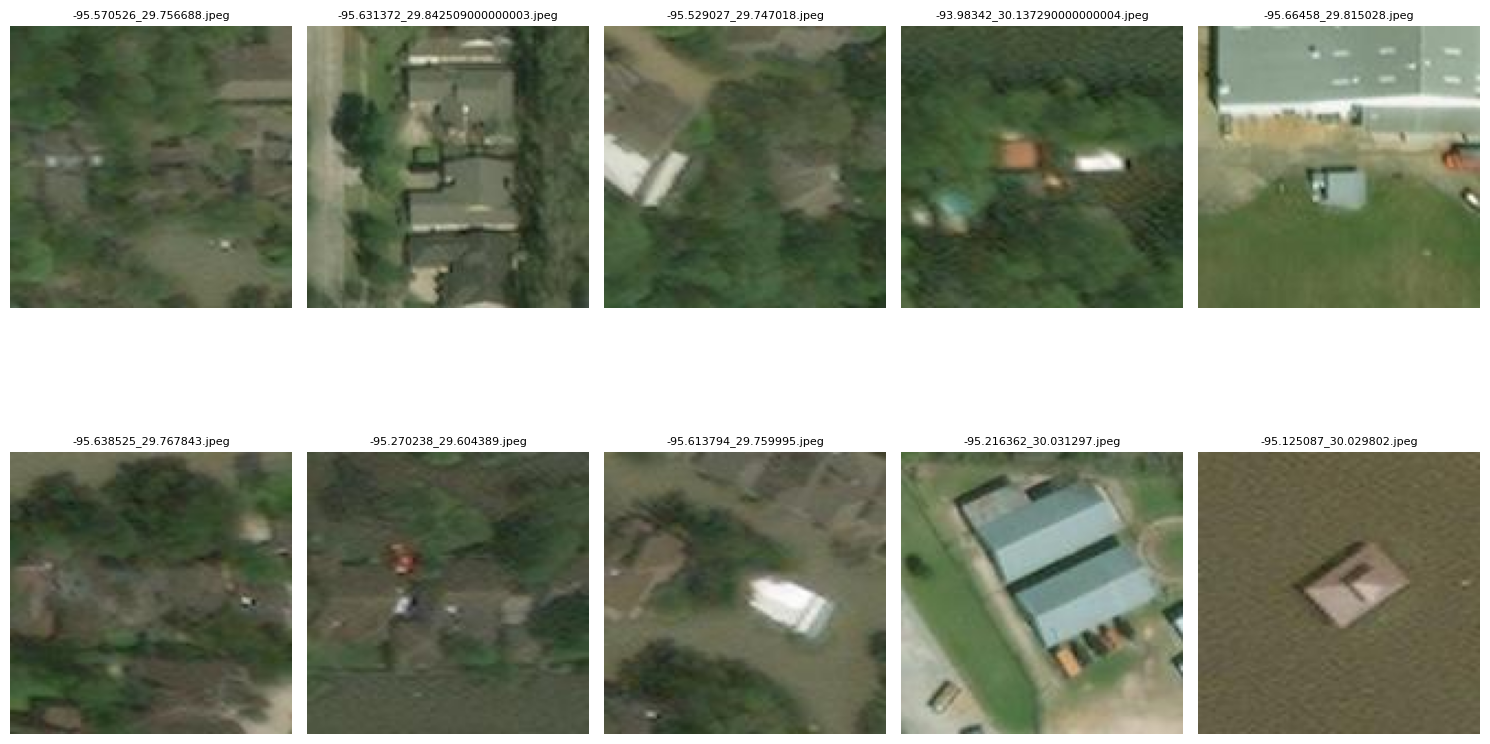

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import random

image_paths = []
# Define common image extensions
image_extensions = ('.jpg', '.jpeg', '.png', '.gif', '.bmp', '.tiff')

for dirpath, _, filenames in os.walk(extraction_path):
    for filename in filenames:
        if filename.lower().endswith(image_extensions):
            image_paths.append(os.path.join(dirpath, filename))

print(f"Found {len(image_paths)} image files.")

# Randomly select a small number of images to display
num_samples = min(10, len(image_paths)) # Display up to 10 images, or fewer if less are available
sampled_image_paths = random.sample(image_paths, num_samples)

print(f"Displaying {num_samples} sample images:")

# Display the sampled images
plt.figure(figsize=(15, 10))
for i, img_path in enumerate(sampled_image_paths):
    try:
        img = Image.open(img_path)
        plt.subplot(2, 5, i + 1) # Adjust subplot grid as needed
        plt.imshow(img)
        plt.title(os.path.basename(img_path), fontsize=8)
        plt.axis('off')
    except Exception as e:
        print(f"Could not open or display image {img_path}: {e}")
        # Optionally, remove the path from the list if it's corrupted
plt.tight_layout()
plt.show()

In [ ]:
corrupted_image_paths = []

print("Checking for corrupted images...")
for img_path in image_paths:
    try:
        with Image.open(img_path) as img:
            img.verify() # Verify image integrity
    except (IOError, SyntaxError, Exception) as e:
        print(f"Corrupted image detected: {img_path} - {e}")
        corrupted_image_paths.append(img_path)

print(f"\nFound {len(corrupted_image_paths)} corrupted images.")
if corrupted_image_paths:
    print("Corrupted image paths:")
    for path in corrupted_image_paths:
        print(f"- {path}")
else:
    print("No corrupted images found.")

Checking for corrupted images...

Found 0 corrupted images.
No corrupted images found.


In [ ]:
unique_dimensions = set()
unique_channels = set()

print("Verifying image dimensions and channels...")
for img_path in image_paths:
    try:
        with Image.open(img_path) as img:
            unique_dimensions.add(img.size) # (width, height)
            unique_channels.add(len(img.getbands())) # Number of channels (e.g., 3 for RGB, 1 for grayscale)
    except Exception as e:
        print(f"Could not read dimensions or channels for {img_path}: {e}")

print(f"\nUnique image dimensions found: {unique_dimensions}")
if len(unique_dimensions) == 1:
    print("All images have consistent dimensions.")
else:
    print("WARNING: Inconsistent image dimensions found!")

print(f"Unique image channel counts found: {unique_channels}")
if len(unique_channels) == 1:
    print("All images have consistent channel counts.")
else:
    print("WARNING: Inconsistent image channel counts found!")

Verifying image dimensions and channels...

Unique image dimensions found: {(128, 128)}
All images have consistent dimensions.
Unique image channel counts found: {3}
All images have consistent channel counts.
